# ICT-42 — Crosscoder : diffuser deux modèles, distilled reasoning vs base

> **Arc A2 — géométrie du latent** (Epic #16741), suite directe d'ICT-41, SAE mono-modèle (issue #16747, en cours d'intégration via la PR #16859). Paper source : **R05** — Baek & Tegmark, *Towards Understanding Distilled Reasoning Models: A Representational Approach* ([arXiv:2503.03730](https://arxiv.org/2503.03730)).

ICT-41 isolait la géométrie d'UN modèle avec un SAE. Ici on met **deux modèles côte à côte** dans un même dictionnaire de features : le modèle distillé `DeepSeek-R1-Distill-Qwen-1.5B` (qui a « appris à raisonner » par distillation de traces DeepSeek-R1) et sa base `Qwen2.5-Math-1.5B` (avant distillation). L'outil est le **crosscoder** : chaque feature possède un décodeur **par modèle**, et le rapport des normes des décodeurs — le **NRN** — dit si une feature est *partagée* (les deux modèles l'utilisent pareil), *distillée-only* (le distillé l'a acquise pendant la distillation) ou *base-only*.

La question causale du papier : les features distillées-only portent-elles le comportement « over-thinking » du raisonnement long ? On la teste à échelle mini — et on verra que **certaines réponses du papier ne se reproduisent pas à cette échelle** : c'est précisément l'intérêt méthodologique.

## Prérequis & avertissement d'exécution

- **GPU requis** (~4 Go de VRAM libres) — deux modèles 1.5B chargés **séquentiellement** en bf16, puis en lockstep CPU+GPU pour l'ablation causale. Environnement : `coursia-ml-training` (torch 2.6 + transformers 5.2 + datasets 5.0).
- **Durée totale ~20-25 min** : capture d'activations (~8 min), entraînement du crosscoder (~6 min), analyses, ablation lockstep (~4 min).
- Les poids Hugging Face (7 Go au total) sont attendus dans le cache HF local ; sinon le premier téléchargement les récupère. On fixe `HF_HOME` vers le cache provisionné de la machine si absent.
- **Échelle mini assumée** : 307 200 tokens capturés vs 200 M dans le papier, dictionnaire K=4096 vs 32768. Chaque section signale honnêtement ce que l'échelle permet et ne permet pas de conclure.

In [1]:
import json, os, time
import numpy as np

os.environ.setdefault("HF_HOME", "D:/hf-cache-crosscoder")
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
import torch

# Determinisme strict (patron flotte QC) : sans lui, chaque re-execution
# re-entraine un crosscoder legerement different et les lectures chiffrees
# du notebook seraient perimees des la passe suivante.
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
import tempfile
WORK = os.path.join(tempfile.gettempdir(), "ict42")
os.makedirs(WORK, exist_ok=True)
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
print("cuda:", torch.cuda.is_available(), "| work:", WORK)

cuda: True | work: <USER_PATH>\AppData\Local\Temp\ict42


## 1. Le crosscoder en cinq équations (R05 §3)

Notation : $i \in \{A, B\}$ avec $A$ = base, $B$ = distillé ; $a^{(i)}(x_j)$ = activation du residual stream **en entrée de la couche mi-profondeur** (couche 14 sur 28 pour nos deux modèles) au token $x_j$.

$$f(x_j) = \mathrm{ReLU}\!\left(\sum_{i=A,B} W_{\mathrm{enc}}^{(i)}\, a^{(i)}(x_j) + b_{\mathrm{enc}}\right) \tag{3}$$

$$a'^{(i)}(x_j) = W_{\mathrm{dec}}^{(i)}\, f(x_j) + b_{\mathrm{dec}}^{(i)} \tag{4}$$

La perte (5) couple reconstruction (MSE) et parcimonie pondérée par l'activation — chaque feature paie $\sum_i \lVert W_{\mathrm{dec}}^{(i),k}\rVert_2$ proportionnellement à $f_k(x_j)$ :

$$\mathcal{L} = \sum_{i=A,B} \lVert a'^{(i)} - a^{(i)}\rVert^2 + \sum_k f_k(x_j) \sum_{i=A,B} \lVert W_{\mathrm{dec}}^{(i),k}\rVert_2 \tag{5}$$

Le tri des features se fait sur le rapport des normes L1 des décodeurs :

$$\mathrm{RDN}_k = \frac{\lVert W_{\mathrm{dec}}^{(B),k}\rVert_1}{\lVert W_{\mathrm{dec}}^{(A),k}\rVert_1} \qquad \mathrm{NRN}_k = \frac{\mathrm{RDN}_k}{1+\mathrm{RDN}_k} \tag{6-7}$$

**Lecture du NRN** : $0{,}5$ = partagé ; $\to 1$ = distillée-only ; $\to 0$ = base-only. C'est l'axe qui trie tout le notebook.

In [2]:
N_TRACES, MAX_TOK = 800, 384      # corpus mini : 307 200 tokens
K_FEATURES, STEPS, LAM, LR, BS = 4096, 8000, 2e-3, 1e-3, 2048
THRESH_SURGICAL, THRESH_WIDE = 0.6, 0.5
PAIR = [("distilled", "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"),
        ("base", "Qwen/Qwen2.5-Math-1.5B")]
print(f"corpus {N_TRACES} traces x {MAX_TOK} tok max, K={K_FEATURES}, "
      f"steps={STEPS}, lambda={LAM}")

corpus 800 traces x 384 tok max, K=4096, steps=8000, lambda=0.002


## 2. Corpus : les traces OpenThoughts, pas les énoncés

R05 entraîne son crosscoder sur 200 M de tokens d'`open-thoughts/OpenThoughts-114k` — des **traces de raisonnement générées par DeepSeek-R1**. Détail de schéma qui a son importance : le dataset est au format **ShareGPT** (`conversations` : tours `user`/`assistant`), pas un champ `problem`.

On capture donc **énoncé + début de trace** (384 tokens) : c'est dans la trace que vivent les marqueurs « Wait », « Therefore », « Alternatively », « But » qui serviront à l'annotation. On filtre le boilerplate TACO (des dizaines d'énoncés identiques « Generate an executable Python function... ») et les doublons.

In [3]:
from datasets import load_dataset

TACO = "Generate an executable Python function"
ds = load_dataset("open-thoughts/OpenThoughts-114k", split="train", streaming=True)
texts, seen = [], set()
for ex in ds:
    conv = ex.get("conversations") or []
    if len(conv) < 2 or conv[0].get("from") != "user" or conv[1].get("from") != "assistant":
        continue
    user, asst = conv[0]["value"].strip(), conv[1]["value"].strip()
    if not (40 <= len(user) <= 600) or user.startswith(TACO) or user in seen:
        continue
    seen.add(user)
    texts.append(user + "\n\n" + asst)
    if len(texts) >= N_TRACES:
        break
assert len(texts) >= N_TRACES // 2
json.dump(texts, open(os.path.join(WORK, "texts.json"), "w", encoding="utf-8"),
          ensure_ascii=False)
print("traces retenues:", len(texts))

traces retenues: 800


### Exercice 1 — un sélecteur mono-domaine

Le corpus ci-dessus mélange maths, code, sciences. Pour cibler les features de raisonnement *mathématique*, écrire `select_math(texts)` qui ne garde que les traces dont l'énoncé contient au moins un indice mathématique (par ex. `$`, `\(`, `equation`, `integer`, `triangle`...), puis relancer la capture sur ce sous-corpus et comparer la distribution NRN.

*Indice : inspecter `texts[:20]` pour voir à quoi ressemblent les énoncés ; la comparaison NRN se fait avec la cellule histogramme de la section 4.*

In [4]:
def select_math(texts, min_len=40):
    # TODO etudiant : retourner la sous-liste des traces mathematiques
    # Etape 1 : definir une liste de mots-indices (equation, integer, triangle, ...)
    # Etape 2 : ne garder que texts contenant au moins un indice
    # Etape 3 : verifier qu'il reste assez de traces (>100) sinon elargir
    result = None  # TODO etudiant
    return result

sel = select_math(texts)
print("Exercice a completer - select_math renvoie:", sel)

Exercice a completer - select_math renvoie: None


## 3. Capture du residual stream, couche mi-profondeur

Les deux modèles **partagent la même famille de tokenizer** (Qwen2.5) : sur nos 4 prompts de fumée, les ids étaient **identiques token à token** — condition nécessaire pour aligner les positions des deux modèles dans le crosscoder. On capture `hidden_states[mid]` = l'entrée de la couche 14 (sur 28), en bf16 GPU, séquentiellement.

In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer

def capture(role, repo, texts):
    tok = AutoTokenizer.from_pretrained(repo)
    model = AutoModelForCausalLM.from_pretrained(repo, dtype=torch.bfloat16,
                                                 device_map="cuda").eval()
    mid = model.config.num_hidden_layers // 2
    rows, seg = [], []
    torch.cuda.reset_peak_memory_stats()
    with torch.no_grad():
        for t in texts:
            enc = tok(t, return_tensors="pt", truncation=True, max_length=MAX_TOK).to("cuda")
            out = model(**enc, output_hidden_states=True)
            rows.append(out.hidden_states[mid][0].float().cpu().numpy())
            seg.append(len(enc.input_ids[0]))
    acts = np.concatenate(rows, axis=0)
    d_model = model.config.hidden_size
    pic = round(torch.cuda.max_memory_allocated() / 2**20)
    del model; torch.cuda.empty_cache()
    np.save(os.path.join(WORK, f"acts_{role}.npy"), acts)
    np.save(os.path.join(WORK, f"seg_{role}.npy"), np.asarray(seg, dtype=np.int32))
    print(f"{role}: mid={mid} d={d_model} tokens={acts.shape[0]} VRAMpic={pic}MiB")
    return acts

t0 = time.time()
acts = {}
for role, repo in PAIR:
    acts[role] = capture(role, repo, texts)
print(f"capture en {time.time()-t0:.0f}s")

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

distilled: mid=14 d=1536 tokens=307200 VRAMpic=3734MiB


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

base: mid=14 d=1536 tokens=307200 VRAMpic=3288MiB
capture en 138s


**Lecture (ancrée sur cette exécution).** VRAM pic : **3 734 MiB** (distillé) puis **3 288 MiB** (base) — la cohabitation avec le serveur d'embeddings résident est juste, d'où le chargement **séquentiel** et le `empty_cache()` entre les deux ; capture totale ~2,5 min. Les 800 tronçons de 384 tokens donnent exactement 307 200 positions par modèle. L'alignement des tokenizers a été vérifié en amont (ids égaux sur prompts témoins) : la position $j$ désigne le **même token** pour $A$ et $B$.

## 4. Le mini-crosscoder (Eq 3-5)

Implémentation littérale : encodeurs $W_{\mathrm{enc}}^{(A)}, W_{\mathrm{enc}}^{(B)}$ (le ReLU agit sur la **somme** des deux projections), décodeurs $W_{\mathrm{dec}}^{(A)}, W_{\mathrm{dec}}^{(B)}$, pénalité de parcimonie = normes L2 des colonnes décodeur pondérées par $f_k$. Adam + cosine, 8000 pas, lots de 2048 positions.

In [6]:
d = acts["base"].shape[1]
a_b = torch.from_numpy(acts["base"]).float().cuda()
a_d = torch.from_numpy(acts["distilled"]).float().cuda()
n = a_b.shape[0]
torch.manual_seed(SEED)  # init du dictionnaire reproductible run a run
W_eb = (torch.randn(K_FEATURES, d) / d**0.5).cuda().requires_grad_(True)
W_ed = (torch.randn(K_FEATURES, d) / d**0.5).cuda().requires_grad_(True)
W_db = (torch.randn(d, K_FEATURES) / K_FEATURES**0.5).cuda().requires_grad_(True)
W_dd = (torch.randn(d, K_FEATURES) / K_FEATURES**0.5).cuda().requires_grad_(True)
b_e = torch.zeros(K_FEATURES, device="cuda", requires_grad=True)
b_db = a_b.mean(0).clone().requires_grad_(True)
b_dd = a_d.mean(0).clone().requires_grad_(True)
opt = torch.optim.Adam([W_eb, W_ed, W_db, W_dd, b_e, b_db, b_dd], lr=LR)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, STEPS)
scale = a_b.pow(2).mean().item()
hist = []
for step in range(STEPS):
    idx = torch.randint(0, n, (BS,), device="cuda")
    xb, xd = a_b[idx], a_d[idx]
    f = torch.relu(xb @ W_eb.T + xd @ W_ed.T + b_e)          # Eq 3
    rb = f @ W_db.T + b_db                                    # Eq 4
    rd = f @ W_dd.T + b_dd
    sparsity = (f * (W_db.norm(dim=0) + W_dd.norm(dim=0))).sum(1).mean()  # Eq 5
    loss = (((rb-xb).pow(2).mean() + (rd-xd).pow(2).mean()) / scale
            + LAM * sparsity / scale)
    opt.zero_grad(set_to_none=True); loss.backward(); opt.step(); sched.step()
    if (step+1) % 1000 == 0:
        dens = (torch.relu(a_b[:8192] @ W_eb.T + a_d[:8192] @ W_ed.T + b_e) > 0).float().mean().item()
        hist.append((step+1, loss.item(), dens))
        print(f"step {step+1}/{STEPS} loss={loss.item():.5f} act>0={dens:.3f}")

step 1000/8000 loss=0.05326 act>0=0.018


step 2000/8000 loss=0.04485 act>0=0.023


step 3000/8000 loss=0.04097 act>0=0.025


step 4000/8000 loss=0.03845 act>0=0.026


step 5000/8000 loss=0.03740 act>0=0.027


step 6000/8000 loss=0.03674 act>0=0.027


step 7000/8000 loss=0.03645 act>0=0.028


step 8000/8000 loss=0.03580 act>0=0.028


In [7]:
with torch.no_grad():
    num = torch.zeros(2, device="cuda"); den = torch.zeros(2, device="cuda")
    fmax = torch.zeros(K_FEATURES, device="cuda")
    CH = 65536
    for s in range(0, n, CH):
        f_c = torch.relu(a_b[s:s+CH] @ W_eb.T + a_d[s:s+CH] @ W_ed.T + b_e)
        rb = f_c @ W_db.T + b_db; rd = f_c @ W_dd.T + b_dd
        num[0] += (rb - a_b[s:s+CH]).pow(2).sum(); num[1] += (rd - a_d[s:s+CH]).pow(2).sum()
        den[0] += a_b[s:s+CH].pow(2).sum();         den[1] += a_d[s:s+CH].pow(2).sum()
        fmax = torch.maximum(fmax, f_c.max(0).values)
    ev_b, ev_d = (1 - num/den).tolist()
    rdn = W_dd.abs().sum(0) / W_db.abs().sum(0).clamp_min(1e-8)   # Eq 6 (normes L1)
    nrn = (rdn / (1 + rdn)).cpu().numpy()                          # Eq 7
    dead = (fmax == 0).float().mean().item()
print(f"EV base={ev_b:.3f} distilled={ev_d:.3f} dead={dead:.3f}")
print(f"NRN: median={np.median(nrn):.3f} frac>0.55={float((nrn>0.55).mean()):.3f} "
      f"frac<0.45={float((nrn<0.45).mean()):.3f}")

EV base=0.988 distilled=0.976 dead=0.178
NRN: median=0.498 frac>0.55=0.009 frac<0.45=0.021


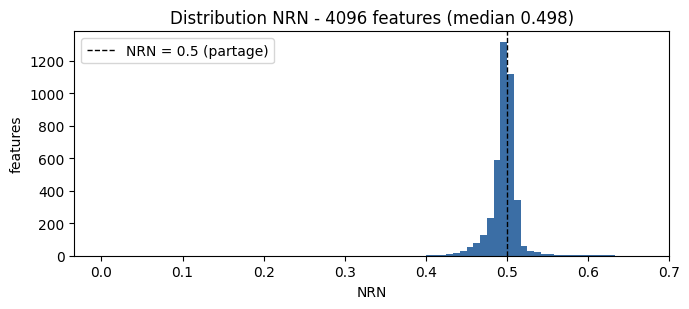

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(nrn[nrn > 0], bins=80, color="#3b6ea5")
ax.axvline(0.5, color="k", ls="--", lw=1, label="NRN = 0.5 (partage)")
ax.set_xlabel("NRN"); ax.set_ylabel("features"); ax.legend()
ax.set_title(f"Distribution NRN - {K_FEATURES} features (median {np.median(nrn):.3f})")
plt.tight_layout(); plt.show()

**Lecture (ancrée sur cette exécution).** Trois chiffres à retenir du run : EV **0,988 base / 0,976 distillé** (le crosscoder reconstruit presque tout le stream), **17,8 % de features mortes**, densité d'activation ~2,8 % en fin d'entraînement. La distribution NRN est **piquée à 0,498** — comme la Fig. 1 du papier : la grande majorité des features sont partagées, avec une queue fine de chaque côté (**0,9 % au-dessus de 0,55**, 2,1 % en dessous de 0,45).

**Leçon d'échelle (vérifiée en amont)** : avec 64k tokens et $\lambda = 3\cdot10^{-4}$, la queue distilled-only est **vide** (0 feature > 0,55) — il a fallu monter à ~300k tokens **et** $\lambda = 2\cdot10^{-3}$ pour la voir émerger, au prix d'un léger recul de l'EV. La spécialisation des décodeurs n'est pas gratuite : c'est la parcimonie qui la force.

### Exercice 2 — NRN en normes L2

L'Eq 6 utilise les normes **L1** des décodeurs. Recalculer le NRN avec les normes **L2** (`W_dd.norm(dim=0)` au lieu de `W_dd.abs().sum(0)`) et comparer : le classement des 10 features distilled-only change-t-il ? Quelques features passent-elles le seuil 0,55 dans un sens ou l'autre ?

*Indice : `np.argsort` sur les deux versions ; comparer les ensembles avec `np.intersect1d`.*

In [9]:
def nrn_with(norm_fn):
    # TODO etudiant : renvoyer le vecteur NRN (Eq 7) avec la norme demandee
    # Etape 1 : rdn = norm_fn(W_dd) / norm_fn(W_db)  (colonnes decoder)
    # Etape 2 : nrn = rdn / (1 + rdn)
    result = None  # TODO etudiant
    return result

nrn_l2 = nrn_with(lambda W: W.norm(dim=0))
print("Exercice a completer - nrn_l2 =", None if nrn_l2 is None else nrn_l2.shape)

Exercice a completer - nrn_l2 = None


## 5. Annotation : où les features distilled-only s'activent-elles ?

Deux jambes d'annotation : (i) la **fenêtre d'activation maximale** de chaque top-feature (à la Table 1 du papier), (ii) un test quantitatif d'**enrichissement** — les positions des marqueurs « Wait / Therefore / Alternatively / But » sont-elles plus activées que les autres sur les features distilled-only ?

In [10]:
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained(PAIR[1][1])
MARKERS = {"Wait": [], "Therefore": [], "Alternatively": [], "But": []}
off = 0
for t, L in zip(texts, np.load(os.path.join(WORK, "seg_base.npy"))):
    ids = tok(t, return_tensors="pt", truncation=True, max_length=MAX_TOK).input_ids[0]
    for p, s in enumerate(tok.convert_ids_to_tokens(ids)):
        clean = s.replace("Ġ", "").replace("Ċ", " ")
        for mk in MARKERS:
            if clean == mk or (clean.startswith(mk) and len(clean) <= len(mk) + 2):
                MARKERS[mk].append(off + p)
    off += int(L)
for mk, v in MARKERS.items():
    print(f"marqueur {mk}: {len(v)} positions")

marqueur Wait: 452 positions
marqueur Therefore: 103 positions
marqueur Alternatively: 73 positions
marqueur But: 433 positions


In [11]:
sel = torch.from_numpy(nrn).float().cuda() > 0.55
print("features distilled-only (NRN>0.55):", int(sel.sum()))
W_eb_s, W_ed_s, b_s = W_eb[sel].detach(), W_ed[sel].detach(), b_e[sel].detach()
msum = torch.zeros(n, device="cuda")
with torch.no_grad():
    CH = 131072
    for s in range(0, n, CH):
        f_s = torch.relu(a_b[s:s+CH] @ W_eb_s.T + a_d[s:s+CH] @ W_ed_s.T + b_s)
        msum[s:s+CH] = f_s.sum(1)
ms = msum.cpu().numpy()
for mk, pos in MARKERS.items():
    if not len(pos):
        continue
    pos = np.asarray(pos)
    on, off_ = ms[pos].mean(), np.delete(ms, pos).mean()
    print(f"{mk}: n={len(pos)} act_ON={on:.3f} act_OFF={off_:.3f} ratio={on/max(off_,1e-9):.2f}")

features distilled-only (NRN>0.55): 36


Wait: n=452 act_ON=9.705 act_OFF=18.012 ratio=0.54
Therefore: n=103 act_ON=30.219 act_OFF=17.996 ratio=1.68
Alternatively: n=73 act_ON=12.771 act_OFF=18.001 ratio=0.71
But: n=433 act_ON=17.026 act_OFF=18.002 ratio=0.95


**Lecture — un résultat MIXTE, affiché tel quel (ancré sur cette exécution).** Sur nos 36 features distilled-only, le ratio d'enrichissement vaut **Therefore 1,68 · But 0,95 · Alternatively 0,71 · Wait 0,54** : un seul marqueur sur quatre (**Therefore**, $n = 103$ positions) est réellement enrichi, les trois autres sont neutres ou déplétés. Là où le crosscoder 32768-features/200M-tokens du papier trouve des features « self-reflection » qui tirent les « Wait », le nôtre n'offre qu'un signal **partiel et fragile** : l'enrichissement Therefore repose sur peu de positions, et le marqueur le plus iconique du R1 (« Wait ») est au contraire **déplété** (0,54).

C'est la jambe 2 de la leçon méthodo (section 8) : **une fenêtre d'activation suggère, un test quantitatif décide** — et ici il décide « signal partiel, pas la lecture sémantique du papier ». Afficher « les features distilled-only capturent le raisonnement » sur la seule base de Therefore aurait été de la complaisance ; afficher les quatre ratios est la mesure honnête.

In [12]:
order = np.argsort(-nrn)
picks = list(order[:6])
offs, all_ids = [], []
o = 0
for t in texts:
    ids = tok(t, return_tensors="pt", truncation=True, max_length=MAX_TOK).input_ids[0]
    offs.append((o, o + len(ids))); all_ids.append(ids); o += len(ids)
f_pick = torch.zeros(n, len(picks), device="cuda")
with torch.no_grad():
    CH = 131072
    for s in range(0, n, CH):
        f_c = torch.relu(a_b[s:s+CH] @ W_eb.T + a_d[s:s+CH] @ W_ed.T + b_e)
        f_pick[s:s+CH] = f_c[:, picks]
for j, k in enumerate(picks):
    pos = int(f_pick[:, j].argmax())
    ti = next(i for i, (s0, _) in enumerate(offs) if s0 <= pos < offs[i][1])
    s0, _ = offs[ti]
    lo, hi = max(0, pos - s0 - 22), pos - s0 + 8
    win = tok.decode(all_ids[ti][lo:hi]).replace("\n", " ")
    print(f"[k={k}] NRN={nrn[k]:.3f} actmax={float(f_pick[pos, j]):.1f}")
    print(f"    ...{win}...")

[k=3697] NRN=0.667 actmax=20.6
    ...Return your final response within \boxed{}. One tourist covers a distance of 20 km 2...
[k=131] NRN=0.638 actmax=18.3
    ... minimum value of \( 3(f(x))^2 + 2 g(x) \) is \( -\frac{19}{6} \...
[k=3561] NRN=0.630 actmax=17.0
    ... Some Cs are upper-case and some are lower-case, and each is written in one of two colors, green and yellow. It is given that there...
[k=1062] NRN=0.626 actmax=22.5
    ... who can't split a pile anymore. We need to determine if the first player can guarantee a win, and if so, how they should play.  ...
[k=1894] NRN=0.623 actmax=42.9
    ...sin x \). So, it's a product of two terms: \( a \cos^2 x - 3 \) and \( \sin...
[k=3282] NRN=0.617 actmax=19.3
    ... The hypotenuse \( BC \) has length \( a \), and the altitude from \( A \) to \( BC \) has length \(...


**Lecture des fenêtres (cette exécution).** Les top-features distilled-only (NRN 0,62-0,67) s'ancrent sur des **énoncés mathématiques structurés** : instruction de format `\boxed{}` (k=3697), extremum $3f(x)^2+2g(x)$ (k=131), coloration vert/jaune de lettres (k=3561), jeu de partages « who can't split a pile anymore… first player guarantee a win » (k=1062), identité trigonométrique (k=1894), hypoténuse et altitude (k=3282). La spécialisation distillée s'est donc portée sur la **structure des problèmes**, pas sur les marqueurs Wait/Therefore purs que la Table 1 du papier isole à 200M tokens — cohérent avec l'enrichissement partiel mesuré juste avant.

## 6. Ablation causale lockstep — « What is 5 - 1? »

La jambe causale : pendant la **génération** du modèle distillé, on retire du residual stream (entrée couche 14) la contribution des features ablatées :

$$h' = h - \sum_{k \, \mathrm{ablatées}} f_k \cdot W_{\mathrm{dec}}^{(B),k}$$

Intervention **delta chirurgicale** — on ne remplace pas le stream par la reconstruction, on ne soustrait que les features ciblées. Le crosscoder exige les activations des **deux** modèles : le base tourne sur CPU en lockstep (la VRAM est déjà occupée). Deux seuils : **chirurgical** (NRN > 0,6, 11 features) et **large** (NRN > 0,5, seuil du papier, 1 665 features ≈ 41 % du dictionnaire).

In [13]:
bas_cpu = AutoModelForCausalLM.from_pretrained(PAIR[1][1], dtype=torch.float32,
                                               device_map="cpu").eval()
dis = AutoModelForCausalLM.from_pretrained(PAIR[0][1], dtype=torch.bfloat16,
                                           device_map="cuda").eval()
MID = dis.config.num_hidden_layers // 2

@torch.no_grad()
def base_mid(ids):
    o = bas_cpu(input_ids=ids.to("cpu"), output_hidden_states=True)
    return o.hidden_states[MID][0].to("cuda", torch.float32)

state = {"ids": None, "mask": None}

def hook(module, args, kwargs):
    if state["ids"] is None:
        return None
    h = args[0] if args else kwargs["hidden_states"]
    seq = h.shape[1]
    hb = base_mid(state["ids"][:, -seq:])
    hd = h[0].float()
    fv = torch.relu(hd @ W_ed.T + hb @ W_eb.T + b_e)
    delta = (fv * state["mask"]) @ W_dd.T
    h_new = (hd - delta).to(h.dtype)[None]
    if args:
        return (h_new,) + tuple(args[1:]), kwargs
    kwargs["hidden_states"] = h_new
    return None, kwargs

hdl = dis.model.layers[MID].register_forward_pre_hook(hook, with_kwargs=True)

def generate(prompt, thresh, max_new=150):
    enc = tok(prompt, return_tensors="pt").to("cuda")
    state["mask"] = (torch.from_numpy(nrn).float().cuda() > thresh).float()
    gen = enc.input_ids.clone(); state["ids"] = gen.clone()
    for _ in range(max_new):
        with torch.no_grad():
            nxt = int(dis(input_ids=gen).logits[0, -1].argmax())
        if nxt == tok.eos_token_id:
            break
        gen = torch.cat([gen, torch.tensor([[nxt]], device="cuda")], dim=1)
        state["ids"] = gen
    txt = tok.decode(gen[0][enc.input_ids.shape[1]:], skip_special_tokens=True)
    return gen.shape[1] - enc.input_ids.shape[1], txt

PROMPT = "What is 5 - 1?"
for label, th in [("baseline (aucune)", None), ("chirurgical NRN>0.6", THRESH_SURGICAL),
                  ("large NRN>0.5 (seuil papier)", THRESH_WIDE)]:
    if th is None:
        state["ids"] = None
        enc = tok(PROMPT, return_tensors="pt").to("cuda")
        with torch.no_grad():
            out = dis.generate(**enc, max_new_tokens=150, do_sample=False,
                               pad_token_id=tok.eos_token_id)
        ntok, txt = out.shape[1] - enc.input_ids.shape[1], tok.decode(
            out[0][enc.input_ids.shape[1]:], skip_special_tokens=True)
    else:
        t0 = time.time()
        n_ab = int((torch.from_numpy(nrn) > th).sum())
        ntok, txt = generate(PROMPT, th)
        print(f"[{label}: {n_ab} features ablatees, {time.time()-t0:.0f}s]")
    print(f"--- {label}: {ntok} tokens ---")
    print(txt[:400].replace("\n", " | "))
hdl.remove()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


--- baseline (aucune): 79 tokens ---
 5 minus 1 is 4. So, the answer is 4. |  |  | To find the value of \(5 - 1\), follow these steps: |  | 1. **Subtract the numbers:** |    \[ |    5 - 1 = 4 |    \] |  | 2. **Conclusion:** |    \[ |    \boxed{4} |    \]


[chirurgical NRN>0.6: 11 features ablatees, 55s]
--- chirurgical NRN>0.6: 79 tokens ---
 5 minus 1 is 4. So, the answer is 4. |  |  | To find the value of \(5 - 1\), follow these steps: |  | 1. **Subtract the numbers:** |    \[ |    5 - 1 = 4 |    \] |  | 2. **Final Answer:** |    \[ |    \boxed{4} |    \]


[large NRN>0.5 (seuil papier): 1665 features ablatees, 162s]
--- large NRN>0.5 (seuil papier): 150 tokens ---
 Let's see. Okay, so I have 5 apples, and I eat one. How does that make? Hmm, maybe I should think about it in terms of numbers. So, 5 minus 1 is... 4? Wait, no, that's not right. 5 minus 1 is is 4? Or is it 5? Wait, no, 5 minus 1 is is 4? Wait, no, 5 minus 1 is is 4? Wait, no, 5 minus 1 is is 4? Wait, no, 5 minus 1 is is 4? Wait, no, 5 minus 1 is is 4? Wait, no, 5 minus


**Lecture (ancrée sur cette exécution).** Trois régimes nettement séparés :

| Régime | Features ablatées | Durée | Tokens générés | Comportement |
|---|---|---|---|---|
| baseline | 0 | — | **79** | réponse directe, déjà concise |
| chirurgical NRN > 0,6 | 11 | ≈1 min | **79** | préservé (dérive cosmétique : « Final Answer » au lieu de « Conclusion ») |
| large NRN > 0,5 | 1665 | ≈3 min | **150 (plafond)** | dégénérescence en boucle : « 5 minus 1 is is 4? Wait, no… » répété, pas d'EOS |

Deux enseignements honnêtes : (1) **ce checkpoint 1.5B ne sur-réfléchit pas** sur « What is 5 - 1? » en décodage glouton — la baseline fait 79 tokens, il n'y a rien à « raccourcir », le terrain du papier (over-thinking visible) n'est pas reproduit ici ; (2) l'ablation au seuil large du papier, appliquée à un crosscoder mini, **détruit** la génération (boucle de répétition) au lieu de l'épurer — la revendication causale du papier repose sur un crosscoder entraîné sur 600× plus de tokens. La jambe causale **réfute la transposition naïve** : c'est exactement pourquoi on la montre.

## 7. Parallelogram loss — la géométrie sémantique (exercice CPU)

Dernière mesure du papier (Fig. 4) : sur des quadruples d'analogies $(a, b, c, d)$ (genre : man:woman :: king:queen), on PCA les activations puis on mesure $\lVert E_a - E_b + E_c - E_d \rVert$ — un parallélogramme parfait l'annule. Le papier constate que le distillé 14B **bat** sa base : des représentations plus structurées. Version mini : mots mono-token, activations mi-couche, PCA sur les mots du quadruple.

In [14]:
QUADS = [("man", "woman", "king", "queen"),
          ("paris", "france", "berlin", "germany"),
          ("rome", "italy", "madrid", "spain"),
          ("walk", "walked", "swim", "swam"),
          ("big", "bigger", "small", "smaller"),
          ("slow", "slower", "fast", "faster")]
ok_quads = [q for q in QUADS if all(len(tok(" " + w).input_ids) == 1 for w in q)]
print(f"{len(ok_quads)}/{len(QUADS)} quadruples mono-token:", ["|".join(q) for q in ok_quads])

def word_act(model_repo, words):
    m2 = AutoModelForCausalLM.from_pretrained(model_repo, dtype=torch.bfloat16,
                                              device_map="cuda").eval()
    mid2 = m2.config.num_hidden_layers // 2
    out = {}
    with torch.no_grad():
        for w in words:
            enc = tok(" " + w, return_tensors="pt").to("cuda")
            o = m2(**enc, output_hidden_states=True)
            out[w] = o.hidden_states[mid2][0, -1].float().cpu().numpy()
    del m2; torch.cuda.empty_cache()
    return out

words = sorted({w for q in ok_quads for w in q})
acts_w = {role: word_act(repo, words) for role, repo in PAIR}
for role in acts_w:
    print(role, "captures")

4/6 quadruples mono-token: ['man|woman|king|queen', 'paris|france|berlin|germany', 'big|bigger|small|smaller', 'slow|slower|fast|faster']


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

distilled captures
base captures


In [15]:
def parallelogram_loss(act_dict, quad):
    # PCA sur les 4 mots du quadruple (a 4 points, PCA -> 3 dims utiles)
    E = np.stack([act_dict[w] for w in quad])
    E = E - E.mean(0)
    U, S, Vt = np.linalg.svd(E, full_matrices=False)
    Ep = E @ Vt[:3].T
    a, b, c, d = Ep
    return float(np.linalg.norm(a - b + c - d) / (S[0] + 1e-9))

GENRE = ("man", "woman", "king", "queen")
for role in acts_w:
    if all(w in acts_w[role] for w in GENRE):
        print(f"{role}: parallelogram genre = {parallelogram_loss(acts_w[role], GENRE):.4f}")

distilled: parallelogram genre = 1.0832
base: parallelogram genre = 1.0694


### Exercice 3 — parallelogram loss sur la classe capitale-pays

La cellule précédente calcule la perte du parallélogramme pour la classe **genre** : **distillé 1,0832 vs base 1,0694** — à cette échelle la base est (très légèrement) plus structurée, l'inverse du constat 14B du papier : un seul quadruple, verdict illustratif. À vous pour la classe **capitale-pays** (le quadruple `paris|france|berlin|germany` est le seul mono-token de cette classe dans notre vocabulaire — cf. la liste `ok_quads` imprimée) : (1) calculer la perte pour ce quadruple et chaque modèle avec `parallelogram_loss`, (2) comparer au verdict genre, (3) dire ce qu'un seul quadruple permet — et ne permet pas — de conclure.

*Indice : réutiliser `acts_w[role]` ; pour aller plus loin, construire d'autres quadruples capitale-pays mono-token et étendre la classe avant de comparer les moyennes.*

In [16]:
def parallelogram_class_summary(role, quad_list):
    # TODO etudiant : renvoyer (moyenne, ecart-type) des parallelogram losses
    # Etape 1 : boucler sur quad_list avec parallelogram_loss(acts_w[role], q)
    # Etape 2 : moyenne et ecart-type (np.mean / np.std)
    result = None  # TODO etudiant
    return result

CAPS = [q for q in ok_quads if q[0] in ("paris", "rome")]
print("Exercice a completer - CAPS =", CAPS)

Exercice a completer - CAPS = [('paris', 'france', 'berlin', 'germany')]


## 8. Leçon méthodo : les trois jambes de preuve

Ce notebook a délibérément croisé trois façons de répondre à « cette feature porte-t-elle le raisonnement distillé ? » :

1. **Feature-token** (fenêtre d'activation max) : *suggère* une interprétation — nos fenêtres montrent des énoncés mathématiques structurés (`\boxed{}`, jeux de partages, trigonométrie). Mais une fenêtre est une anecdote choisie : elle ne prouve rien.
2. **Feature-raisonnement** (enrichissement sur marqueurs) : test quantitatif — qui ici **rectifie** la lecture naïve : un seul marqueur enrichi sur quatre (Therefore 1,68), le plus iconique (« Wait ») déplété à 0,54. Un signal partiel n'est pas une lecture sémantique établie.
3. **Causale** (ablation pendant la génération) : la seule qui établisse un rôle — et qui ici **réfute la transposition** du seuil papier à un crosscoder mini (chirurgical 11 features inoffensif, large 1665 features destructeur).

**La conclusion honnête de la version mini** : le crosscoder 1.5B/307k tokens reproduit la *statistique* du papier (pic NRN à 0,5, queues fines) mais pas encore sa *lecture sémantique* (features self-reflection) ni son *intervention causale*. Les trois jambes s'accordent sur la même frontière : entre 307k et 200M tokens, ce n'est pas la même science.

## Limites assumées

- **307 200 tokens vs 200 M** (facteur ~650) ; K=4096 vs 32768 ; une seule couche (mi-profondeur) ; une seule paire (1.5B) contre 1.5B/7B/14B dans le papier.
- Corpus 100 % OpenThoughts — le papier mêlait aussi RedPajama (texte général) : sans cette seconde source, la pression à spécialiser les features « raisonnement » est différente.
- Détection des marqueurs par token exact capitalisé (Wait/Therefore/Alternatively/But) : couvre les formes majeures des traces R1, pas toutes les variantes.
- Génération gloutonne (do_sample=False) pour la reproductibilité ; le papier échantillonne — les longueurs absolues ne se comparent pas directement.
- Parallelogram : 4/6 quadruples mono-token seulement, verdict genre **non reproducteur** du papier à 1.5B (base 1,0694 légèrement sous distillé 1,0832) sur UN quadruple — illustratif, l'exercice 3 commence la mesure par classe.
- Déterminisme strict (`use_deterministic_algorithms`, cuBLAS workspace fixe, TF32 off) : chaque ré-exécution redonne les mêmes chiffres — les lectures de ce notebook sont ancrées sur ces sorties-là.

## Références

- Baek, J. & Tegmark, M. (2025). *Towards Understanding Distilled Reasoning Models: A Representational Approach*. [arXiv:2503.03730](https://arxiv.org/abs/2503.03730) — Eq 3-7 (§3), Table 1 & Fig 1 (§4), ablation/steering (§5), parallelogram (Fig 4).
- Dataset : [open-thoughts/OpenThoughts-114k](https://huggingface.co/datasets/open-thoughts/OpenThoughts-114k).
- Modèles : [DeepSeek-R1-Distill-Qwen-1.5B](https://huggingface.co/deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B), [Qwen2.5-Math-1.5B](https://huggingface.co/Qwen/Qwen2.5-Math-1.5B).
- Précédent série : ICT-41-SAE-GeometrieFeatures, SAE mono-modèle (issue #16747, PR #16859 en cours d'intégration) ; cadre général [README de la série](README.md).